In [2]:
# Aumento de datos
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# crea el data set
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.25,
    height_shift_range=0.25,
    shear_range=0.15,
    zoom_range=[0.5, 1.5],
    validation_split=0.2
)

# generar set para entrenamiento y pruebas
data_gen_entrenamiento = datagen.flow_from_directory('dataset/', target_size=(160, 160),
                                                     batch_size=32,subset='training', shuffle=True,class_mode='categorical')
data_gen_pruebas = datagen.flow_from_directory('dataset/', target_size=(160, 160),
                                               batch_size=32, subset='validation', shuffle=True,class_mode='categorical')

Found 240 images belonging to 3 classes.
Found 60 images belonging to 3 classes.


In [3]:
import tensorflow as tf

In [4]:
base_model = tf.keras.applications.MobileNetV2(input_shape=(160,160,3), include_top=False, weights='imagenet')
base_model.trainable = False
model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(3, activation='softmax')
])

2025-09-19 12:32:47.363594: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [5]:
model.compile(loss='categorical_crossentropy',
              optimizer=tf.keras.optimizers.RMSprop(learning_rate=0.001),
              metrics=['acc'])
model_fit = model.fit(data_gen_entrenamiento,
                      steps_per_epoch=2,
                      epochs=100,
                      validation_data = data_gen_pruebas
)

/home/rodrigo/Documentos/Prog/Python/entV/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/100


2025-09-19 12:33:02.052290: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 26214400 exceeds 10% of free system memory.
2025-09-19 12:33:02.803641: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 26214400 exceeds 10% of free system memory.
2025-09-19 12:33:02.858371: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 78643200 exceeds 10% of free system memory.
2025-09-19 12:33:02.918370: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 80621568 exceeds 10% of free system memory.
2025-09-19 12:33:02.989699: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 29491200 exceeds 10% of free system memory.


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step - acc: 0.3750 - loss: 1.4098

/home/rodrigo/Documentos/Prog/Python/entV/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


2/2 ━━━━━━━━━━━━━━━━━━━━ 11s 3s/step - acc: 0.3958 - loss: 1.3996 - val_acc: 0.3833 - val_loss: 2.7671
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step - acc: 0.5208 - loss: 1.9157 - val_acc: 0.5667 - val_loss: 0.9959
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step - acc: 0.6562 - loss: 0.7761 - val_acc: 0.7833 - val_loss: 0.4946
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step - acc: 0.7500 - loss: 0.6033 - val_acc: 0.6167 - val_loss: 0.9406
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step - acc: 0.6042 - loss: 0.8540 - val_acc: 0.7833 - val_loss: 0.5876
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - acc: 0.7812 - loss: 0.6179 - val_acc: 0.8333 - val_loss: 0.3954
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step - acc: 0.8403 - loss: 0.4618 - val_acc: 0.8500 - val_loss: 0.3463
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step - acc: 0.8750 - loss: 0.3862 - val_acc: 0.8833 - val_loss: 0.3410
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - acc: 0.7708 - loss: 0.4871 - val_acc: 0.9333 - va

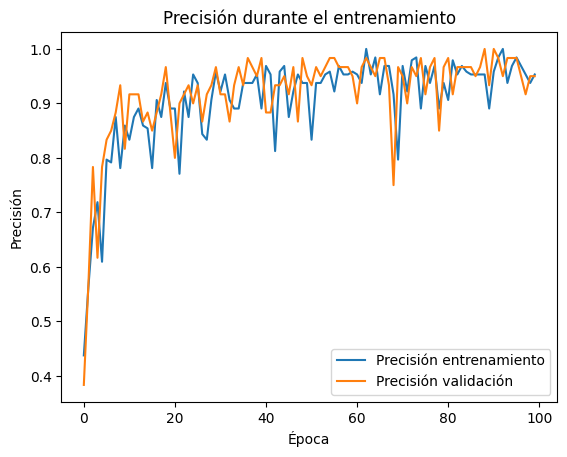

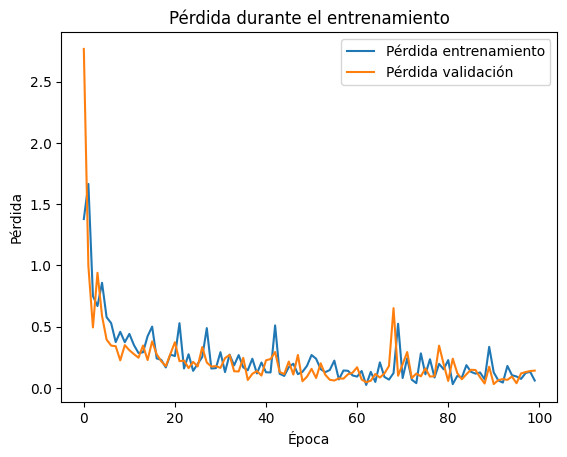

In [6]:
import matplotlib.pyplot as plt

# Graficar precisión
plt.plot(model_fit.history['acc'], label='Precisión entrenamiento')
plt.plot(model_fit.history['val_acc'], label='Precisión validación')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.legend()
plt.title('Precisión durante el entrenamiento')
plt.show()

# Graficar pérdida
plt.plot(model_fit.history['loss'], label='Pérdida entrenamiento')
plt.plot(model_fit.history['val_loss'], label='Pérdida validación')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.legend()
plt.title('Pérdida durante el entrenamiento')
plt.show()

In [7]:
from tensorflow.keras.preprocessing import image
import numpy as np

# Ruta de la imagen a probar
#img_path = 'dataset/desc/Abdullah_Ahmad_Badawi_0001.jpg'  # Cambia por tu imagen
img_path = 'dataset/rodrigo/rostro_10.jpg'  # Cambia por tu imagen
#img_path = 'dataset/ignacio/rostro_30.jpg'  # Cambia por tu imagen

# Cargar y preprocesar la imagen
img = image.load_img(img_path, target_size=(160, 160))
img_array = image.img_to_array(img)
img_array = img_array / 255.0  # Normaliza igual que en el entrenamiento
img_array = np.expand_dims(img_array, axis=0)  # Añade dimensión batch
pred = model.predict(img_array)
print(f"Predicción bruta: {pred[0][0]}")

# Umbral para decidir si es "yo" o "no yo"
pred = model.predict(img_array)
clase = np.argmax(pred[0])
print(f"Clase predicha: {clase}, probabilidades: {pred[0]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Predicción bruta: 9.553115887683816e-06
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
Clase predicha: 2, probabilidades: [9.5531159e-06 5.2957870e-03 9.9469465e-01]


In [8]:
#guarda modelo
#model.export('modelo_exportado')

In [9]:
# Convierte directamente desde la carpeta SavedModel
#converter = tf.lite.TFLiteConverter.from_saved_model('modelo_exportado')
#tflite_model = converter.convert()

# Guarda el modelo TFLite
#with open('modelo_exportado/modelo.tflite', 'wb') as f:
#    f.write(tflite_model)

In [10]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,586,696 (9.87 MB)

 Trainable params: 164,355 (642.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 164,357 (642.02 KB)

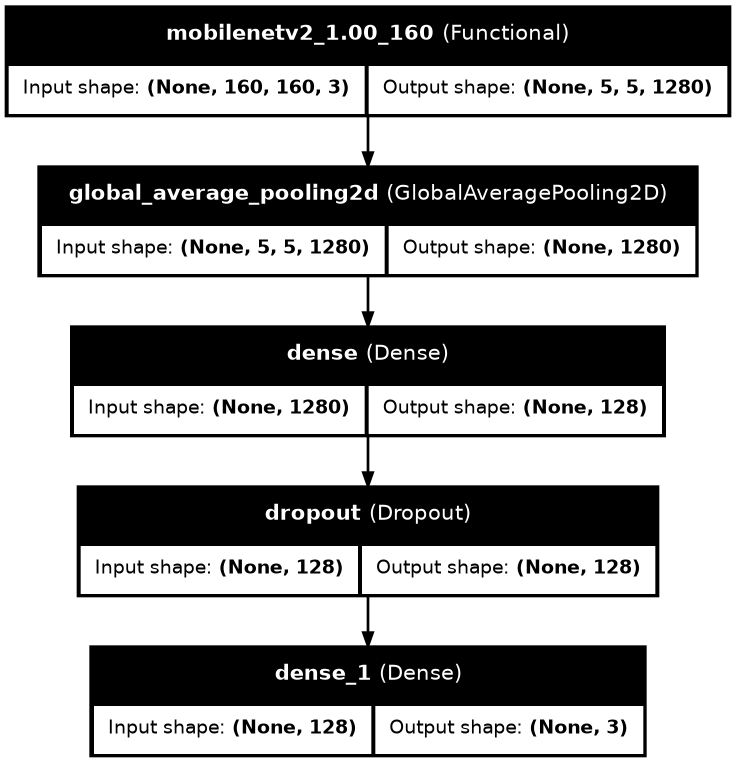

In [11]:
from tensorflow.keras.utils import plot_model
plot_model(
    model,
    to_file='model_architecture.png',
    show_shapes=True,
    show_layer_names=True,
    rankdir='TB',  # 'TB' para vertical, 'LR' para horizontal
    dpi=96,
    layer_range=None,  # Opcional: filtrar capas (ej. ['input_1', 'conv2d_1'])
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 411ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 352ms/step


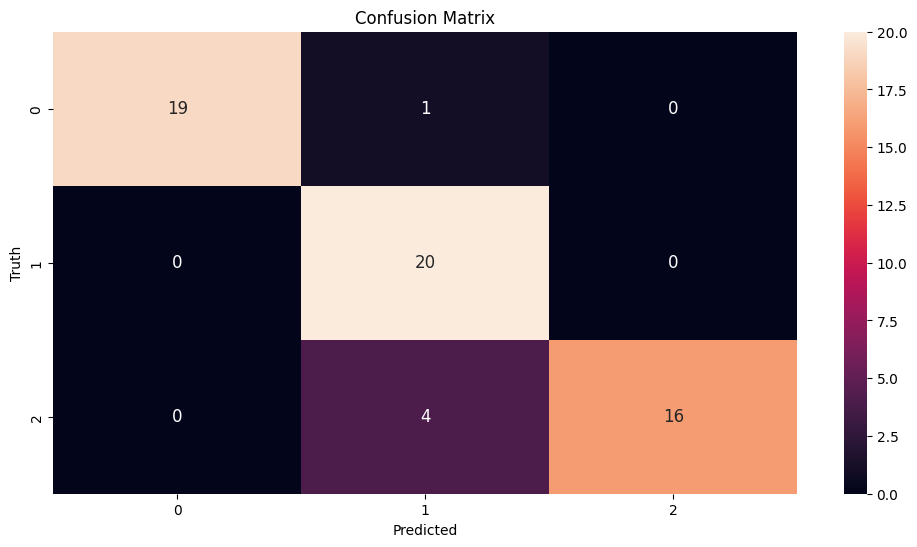

In [14]:
import numpy as np

# Obtener etiquetas verdaderas y predichas
y_true = []
y_pred = []

for i in range(len(data_gen_pruebas)):
    x_batch, y_batch = data_gen_pruebas[i]
    preds = model.predict(x_batch)
    y_true.extend(np.argmax(y_batch, axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

    # Opcional: detener si ya recorriste todo el set de validación
    if (i+1)*data_gen_pruebas.batch_size >= data_gen_pruebas.samples:
        break

import matplotlib.pyplot as plt
cm = tf.math.confusion_matrix(labels=y_true, predictions=y_pred)
# Plot the confusion matrix as a heatmap.
plt.figure(figsize=[12, 6])
import seaborn as sn

sn.heatmap(cm, annot=True, fmt="d", annot_kws={"size": 12})
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Truth")
plt.show()